# Pokemon TCG 2025 Market Price Analysis

## Research Question

How much did the market prices of Pokemon TCG products released in 2025 exceed their retail prices, and were some sets or product types affected more than others?

## Project Overview

For this project, I used Pokemon TCG product data to compare retail price baselines with secondary market prices for products released in 2025. I focused on several common sealed product types, including Booster Packs, Booster Boxes, Elite Trainer Boxes, Booster Bundles, Blisters, and Mini Tins.

The goal of the project is to measure how much these products increased in price and determine whether certain Pokemon sets or product types experienced larger increases than others.

## Data Collection and Setup

I used Python along with the pandas, matplotlib, and requests libraries to collect, clean, analyze, and visualize the data. Product and market price information was collected using the Pokémon TCG API.

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

### API Setup

This project uses the TCG API to collect Pokémon set and product data. The API key is stored as an environment variable and is not included in the public notebook for security.

In [70]:
API_KEY = "YOUR_API_KEY_HERE"

headers = {
    "X-API-Key": API_KEY
}

sets_url = "https://api.tcgapi.dev/v1/games/pokemon/sets"
search_url = "https://api.tcgapi.dev/v1/search"

response = requests.get(
    sets_url,
    headers=headers
)

print(response.status_code)

200


In [71]:
data = response.json()

In [72]:
sets = pd.DataFrame(data['data'])
sets.head()

,id,name,slug,tcgplayer_id,abbreviation,release_date,card_count,image_tcgplayer_id,tcg_group_id,image_url,set_icon_url
0,5500236,ME06: Delta Reign,me06-delta-reign,5500236,None,2026-11-06,21,NaN,24831,NaN,https://tcgplayer-cdn.tcgplayer.com/set_icon/2...
1,5500238,ME: 30th Celebration Classic Collection,me-30th-celebration-classic-collection,5500238,None,2026-09-16,30,NaN,24837,NaN,https://tcgplayer-cdn.tcgplayer.com/set_icon/2...
2,5500219,ME: 30th Celebration,me-30th-celebration,5500219,None,2026-09-16,202,696688.0,24722,https://product-images.tcgplayer.com/fit-in/40...,https://tcgplayer-cdn.tcgplayer.com/set_icon/2...
3,5500216,ME05: Pitch Black,me05-pitch-black,5500216,None,2026-07-17,148,704874.0,24688,https://product-images.tcgplayer.com/fit-in/40...,https://tcgplayer-cdn.tcgplayer.com/set_icon/2...
4,5500213,ME04: Chaos Rising,me04-chaos-rising,5500213,None,2026-05-22,150,693517.0,24655,https://product-images.tcgplayer.com/fit-in/40...,https://tcgplayer-cdn.tcgplayer.com/set_icon/2...


In [73]:
sets.columns

Index(['id', 'name', 'slug', 'tcgplayer_id', 'abbreviation', 'release_date',
       'card_count', 'image_tcgplayer_id', 'tcg_group_id', 'image_url',
       'set_icon_url'],
      dtype='str')

In [74]:
sets.shape

(50, 11)

### Dataset and Variables

The API provides information about Pokemon TCG sets and sealed products. I first used the set data to identify products from sets released in 2025. I then collected product information for those sets using the search API.

The main variables used in my analysis are:

- **searched_set:** the Pokemon TCG set associated with the product
- **name:** the name of the sealed product
- **product_type:** the category I assigned to each product, such as Booster Box or Elite Trainer Box
- **market_price:** the secondary market price provided by the TCG API
- **retail_price:** the retail price baseline used for comparison
- **price_difference:** the dollar difference between market price and retail price
- **markup_percent:** the percentage that the market price is above or below the retail price baseline

In [75]:
sets["release_date"] = pd.to_datetime(sets["release_date"])

In [76]:
sets_2025 = sets[
    sets["release_date"].dt.year == 2025
].copy()

sets_2025[["name", "release_date"]]

,name,release_date
9,ME02: Phantasmal Flames,2025-11-14
10,MEE: Mega Evolution Energies,2025-09-26
11,ME: Mega Evolution Promo,2025-09-26
12,ME01: Mega Evolution,2025-09-26
13,SV: White Flare,2025-07-18
14,SV: Black Bolt,2025-07-18
15,SV10: Destined Rivals,2025-05-30
16,SV09: Journey Together,2025-03-28
17,McDonald's Promos 2024,2025-01-21
18,SV: Prismatic Evolutions,2025-01-17


In [77]:
print("Number of 2025 sets:", len(sets_2025))

Number of 2025 sets: 10


### Removing Promo and Non Standard Sets

I removed promotional and non standard sets because this project focuses on normal retail Pokemon TCG products that regular consumers can purchase. Including promotional or non standard sets could make the product comparisons less consistent.

In [78]:
sets_2025 = sets_2025[
    ~sets_2025["slug"].isin([
        "mee-mega-evolution-energies",
        "me-mega-evolution-promo",
        "mcdonalds-promos-2024"
    ])
].copy()

In [79]:
print("Number of sets:", len(sets_2025))

sets_2025[["name", "release_date"]]

Number of sets: 7


,name,release_date
9,ME02: Phantasmal Flames,2025-11-14
12,ME01: Mega Evolution,2025-09-26
13,SV: White Flare,2025-07-18
14,SV: Black Bolt,2025-07-18
15,SV10: Destined Rivals,2025-05-30
16,SV09: Journey Together,2025-03-28
18,SV: Prismatic Evolutions,2025-01-17


### Testing the Product Search

Before collecting product data for every 2025 set, I tested the API search using Prismatic Evolutions. This helped me see what types of products the API returned and decide which product categories would be useful for the project.

In [80]:
search_url = "https://api.tcgapi.dev/v1/search"

params = {
    "q": "Prismatic Evolutions"
}

response = requests.get(
    search_url,
    headers=headers,
    params=params
)

print(response.status_code)
print(response.text)

200
{"data":[{"id":13502,"name":"Prismatic Evolutions  Binder Collection Case","clean_name":"prismatic evolutions  binder collection case","number":null,"rarity":null,"tcgplayer_id":598488,"product_type":"Sealed Products","foil_only":0,"total_listings":4,"shipping_category_id":4,"game_name":"Pokemon","game_slug":"pokemon","set_name":"SV: Prismatic Evolutions","printing":"Normal","market_price":530,"low_price":690,"median_price":null,"lowest_with_shipping":null,"price_updated_at":"2026-09-13T08:39:37.617Z","image_url":"https://product-images.tcgplayer.com/fit-in/400x400/598488.jpg"},{"id":13496,"name":"Prismatic Evolutions 2-Pack Blister Case","clean_name":"prismatic evolutions 2pack blister case","number":null,"rarity":null,"tcgplayer_id":620024,"product_type":"Sealed Products","foil_only":0,"total_listings":15,"shipping_category_id":4,"game_name":"Pokemon","game_slug":"pokemon","set_name":"SV: Prismatic Evolutions","printing":"Normal","market_price":830.79,"low_price":829.99,"median_p

In [81]:
product_data = response.json()

products = pd.DataFrame(product_data["data"])

products.head()

,id,name,clean_name,number,rarity,tcgplayer_id,product_type,foil_only,total_listings,shipping_category_id,game_name,game_slug,set_name,printing,market_price,low_price,median_price,lowest_with_shipping,price_updated_at,image_url
0,13502,Prismatic Evolutions Binder Collection Case,prismatic evolutions binder collection case,None,NaN,598488,Sealed Products,0,4,4,Pokemon,pokemon,SV: Prismatic Evolutions,Normal,530.00,690.00,NaN,NaN,2026-09-13T08:39:37.617Z,https://product-images.tcgplayer.com/fit-in/40...
1,13496,Prismatic Evolutions 2-Pack Blister Case,prismatic evolutions 2pack blister case,None,NaN,620024,Sealed Products,0,15,4,Pokemon,pokemon,SV: Prismatic Evolutions,Normal,830.79,829.99,991.95,829.99,2026-09-13T08:39:37.617Z,https://product-images.tcgplayer.com/fit-in/40...
2,13479,Prismatic Evolutions 2-Pack Blister [Eevee],prismatic evolutions 2pack blister eevee,None,NaN,609716,Sealed Products,0,14,2,Pokemon,pokemon,SV: Prismatic Evolutions,Normal,36.65,1.50,40.52,40.52,2026-09-13T08:39:37.617Z,https://product-images.tcgplayer.com/fit-in/40...
3,13442,Prismatic Evolutions Accessory Pouch Special C...,prismatic evolutions accessory pouch special c...,None,NaN,606881,Sealed Products,0,44,4,Pokemon,pokemon,SV: Prismatic Evolutions,Normal,75.47,11.99,85.62,72.00,2026-09-13T08:39:37.617Z,https://product-images.tcgplayer.com/fit-in/40...
4,13504,Prismatic Evolutions Accessory Pouch Special C...,prismatic evolutions accessory pouch special c...,None,NaN,629828,Sealed Products,0,4,4,Pokemon,pokemon,SV: Prismatic Evolutions,Normal,NaN,475.00,797.50,475.00,2026-09-13T08:39:37.617Z,https://product-images.tcgplayer.com/fit-in/40...


In [82]:
wanted_names = [
    "Prismatic Evolutions Booster Pack",
    "Prismatic Evolutions Booster Bundle",
    "Prismatic Evolutions 2-Pack Blister [Eevee]",
    "Prismatic Evolutions Elite Trainer Box",
    "Prismatic Evolutions Mini Tin [Espeon]",
    "Prismatic Evolutions Mini Tin [Flareon]",
    "Prismatic Evolutions Mini Tin [Glaceon]",
    "Prismatic Evolutions Mini Tin [Jolteon]"
]

The API returned many different products including cases, exclusive products, and exclusive bundles. I selected the most commonly purchased sealed products. In the case of Prismatic Evolutions this includes the types listed below in my filtered data and the others were excluded because they represent different quantities and purchasing formats.

In [83]:
prismatic_products = products[
    products["name"].isin(wanted_names)
].copy()

prismatic_products

,id,name,clean_name,number,rarity,tcgplayer_id,product_type,foil_only,total_listings,shipping_category_id,game_name,game_slug,set_name,printing,market_price,low_price,median_price,lowest_with_shipping,price_updated_at,image_url
2,13479,Prismatic Evolutions 2-Pack Blister [Eevee],prismatic evolutions 2pack blister eevee,None,NaN,609716,Sealed Products,0,14,2,Pokemon,pokemon,SV: Prismatic Evolutions,Normal,36.65,1.50,40.520,40.52,2026-09-13T08:39:37.617Z,https://product-images.tcgplayer.com/fit-in/40...
6,13118,Prismatic Evolutions Booster Bundle,prismatic evolutions booster bundle,None,NaN,600518,Sealed Products,0,186,3,Pokemon,pokemon,SV: Prismatic Evolutions,Normal,91.11,80.00,99.990,84.99,2026-09-13T08:39:37.617Z,https://product-images.tcgplayer.com/fit-in/40...
10,13109,Prismatic Evolutions Booster Pack,prismatic evolutions booster pack,None,NaN,593294,Sealed Products,0,92,2,Pokemon,pokemon,SV: Prismatic Evolutions,Normal,14.35,7.17,15.080,14.25,2026-09-13T08:39:37.617Z,https://product-images.tcgplayer.com/fit-in/40...
13,13196,Prismatic Evolutions Elite Trainer Box,prismatic evolutions elite trainer box,None,NaN,593355,Sealed Products,0,284,3,Pokemon,pokemon,SV: Prismatic Evolutions,Normal,141.91,1.99,180.000,144.98,2026-09-13T08:39:37.617Z,https://product-images.tcgplayer.com/fit-in/40...
21,13473,Prismatic Evolutions Mini Tin [Espeon],prismatic evolutions mini tin espeon,None,NaN,593458,Sealed Products,0,29,2,Pokemon,pokemon,SV: Prismatic Evolutions,Normal,38.31,12.00,38.990,37.99,2026-09-13T08:39:37.617Z,https://product-images.tcgplayer.com/fit-in/40...
22,13468,Prismatic Evolutions Mini Tin [Flareon],prismatic evolutions mini tin flareon,None,NaN,593457,Sealed Products,0,25,2,Pokemon,pokemon,SV: Prismatic Evolutions,Normal,32.26,10.00,39.465,36.88,2026-09-13T08:39:37.617Z,https://product-images.tcgplayer.com/fit-in/40...
23,13474,Prismatic Evolutions Mini Tin [Glaceon],prismatic evolutions mini tin glaceon,None,NaN,593461,Sealed Products,0,25,2,Pokemon,pokemon,SV: Prismatic Evolutions,Normal,36.20,12.00,42.000,30.97,2026-09-13T08:39:37.617Z,https://product-images.tcgplayer.com/fit-in/40...
24,13477,Prismatic Evolutions Mini Tin [Jolteon],prismatic evolutions mini tin jolteon,None,NaN,593456,Sealed Products,0,31,2,Pokemon,pokemon,SV: Prismatic Evolutions,Normal,34.28,12.00,36.990,34.95,2026-09-13T08:39:37.617Z,https://product-images.tcgplayer.com/fit-in/40...


In [84]:
prismatic_clean = prismatic_products[
    [
        "name",
        "set_name",
        "market_price",
        "low_price",
        "median_price",
        "lowest_with_shipping",
        "price_updated_at"
    ]
].copy()

prismatic_clean

,name,set_name,market_price,low_price,median_price,lowest_with_shipping,price_updated_at
2,Prismatic Evolutions 2-Pack Blister [Eevee],SV: Prismatic Evolutions,36.65,1.50,40.520,40.52,2026-09-13T08:39:37.617Z
6,Prismatic Evolutions Booster Bundle,SV: Prismatic Evolutions,91.11,80.00,99.990,84.99,2026-09-13T08:39:37.617Z
10,Prismatic Evolutions Booster Pack,SV: Prismatic Evolutions,14.35,7.17,15.080,14.25,2026-09-13T08:39:37.617Z
13,Prismatic Evolutions Elite Trainer Box,SV: Prismatic Evolutions,141.91,1.99,180.000,144.98,2026-09-13T08:39:37.617Z
21,Prismatic Evolutions Mini Tin [Espeon],SV: Prismatic Evolutions,38.31,12.00,38.990,37.99,2026-09-13T08:39:37.617Z
22,Prismatic Evolutions Mini Tin [Flareon],SV: Prismatic Evolutions,32.26,10.00,39.465,36.88,2026-09-13T08:39:37.617Z
23,Prismatic Evolutions Mini Tin [Glaceon],SV: Prismatic Evolutions,36.20,12.00,42.000,30.97,2026-09-13T08:39:37.617Z
24,Prismatic Evolutions Mini Tin [Jolteon],SV: Prismatic Evolutions,34.28,12.00,36.990,34.95,2026-09-13T08:39:37.617Z


Before analyzing product prices I checked the selected variables for missing values. The missing price data could affect the comparison between products and may require products to be removed or handled differently.

In [85]:
prismatic_clean.isnull().sum()

name                    0
set_name                0
market_price            0
low_price               0
median_price            0
lowest_with_shipping    0
price_updated_at        0
dtype: int64

To measure how much secondary market prices differ from original retail prices, I compare the TCG API market price with the original retail price of each product. Retail prices are collected separately because they are not included in the TCG API data rather from individual retailers.

### Collecting Products From All 2025 Sets

After testing the API with Prismatic Evolutions, I used the same process to collect product data for all seven sets in the study. The loop goes through each set then searches for its products, and stores the results so they can be combined into one dataset.

In [86]:
all_products = []

for set_name in sets_2025["name"]:

    clean_set_name = set_name.split(": ", 1)[-1]

    params = {
        "q": clean_set_name
    }

    response = requests.get(
        search_url,
        headers=headers,
        params=params
    )

    if response.status_code == 200:
        product_data = response.json()

        temp_products = pd.DataFrame(product_data["data"])

        temp_products["searched_set"] = clean_set_name

        all_products.append(temp_products)

        print(clean_set_name, "-", len(temp_products), "products") 

Phantasmal Flames - 33 products
Mega Evolution - 50 products
White Flare - 26 products
Black Bolt - 45 products
Destined Rivals - 50 products
Journey Together - 49 products
Prismatic Evolutions - 50 products


In [87]:
products_2025 = pd.concat(
    all_products,
    ignore_index=True
)
products_2025.shape

(303, 21)

In [88]:
products_2025[
    ["name", "set_name", "searched_set", "market_price"]
].head(20)

,name,set_name,searched_set,market_price
0,Phantasmal Flames 3 Pack Blister [Sneasel],ME02: Phantasmal Flames,Phantasmal Flames,42.5200
1,Phantasmal Flames 3 Pack Blister [Weavile],ME02: Phantasmal Flames,Phantasmal Flames,42.7300
2,Phantasmal Flames Booster Box,ME02: Phantasmal Flames,Phantasmal Flames,397.5300
3,Phantasmal Flames Booster Box Case,ME02: Phantasmal Flames,Phantasmal Flames,2393.3700
4,Phantasmal Flames Booster Bundle,ME02: Phantasmal Flames,Phantasmal Flames,83.1600
5,Phantasmal Flames Booster Bundle Case,ME02: Phantasmal Flames,Phantasmal Flames,1783.3300
6,Phantasmal Flames Booster Pack,ME02: Phantasmal Flames,Phantasmal Flames,12.6900
7,Phantasmal Flames Booster Pack Art Bundle [Set...,ME02: Phantasmal Flames,Phantasmal Flames,47.1100
8,Phantasmal Flames Build & Battle Box,ME02: Phantasmal Flames,Phantasmal Flames,64.4000
9,Phantasmal Flames Build & Battle Box Display,ME02: Phantasmal Flames,Phantasmal Flames,494.7300


In [89]:
products_2025["searched_set"].value_counts()

searched_set
Mega Evolution          50
Destined Rivals         50
Prismatic Evolutions    50
Journey Together        49
Black Bolt              45
Phantasmal Flames       33
White Flare             26
Name: count, dtype: int64

### Cleaning and Selecting Products

The API search returned several products that were not useful for my comparison, including promotional items, code cards, product bundles, and other non standard products. I filtered the data to focus on common sealed Pokemon TCG products that could be compared across the 2025 sets.

The products kept for the analysis include Booster Packs, Booster Bundles, Booster Boxes, Elite Trainer Boxes, Blisters, and Mini Tins when available.

In [90]:
keep_pattern = (
    r"Booster Pack$|"
    r"Booster Bundle$|"
    r"Booster Box$|"
    r"Elite Trainer Box$|Elite Trainer Box \[|"
    r"3 Pack Blister \[|"
    r"Single Pack Blister \[|"
    r"2-Pack Blister \[|"
    r"Mini Tin \["
)

clean_products = products_2025[
    products_2025["name"].str.contains(
        keep_pattern,
        case=False,
        na=False,
        regex=True
    )
].copy()

In [91]:
clean_products = clean_products[
    ~clean_products["name"].str.contains(
        "Sleeved Booster Pack|Code Card|Set of 2|Set of 3|Set of 4|"
        "Enhanced Booster|Half Booster|Deluxe Booster",
        case=False,
        na=False
    )
].copy()

In [92]:
clean_products[
    ["searched_set", "name", "market_price"]
]

,searched_set,name,market_price
0,Phantasmal Flames,Phantasmal Flames 3 Pack Blister [Sneasel],42.5200
1,Phantasmal Flames,Phantasmal Flames 3 Pack Blister [Weavile],42.7300
2,Phantasmal Flames,Phantasmal Flames Booster Box,397.5300
4,Phantasmal Flames,Phantasmal Flames Booster Bundle,83.1600
6,Phantasmal Flames,Phantasmal Flames Booster Pack,12.6900
10,Phantasmal Flames,Phantasmal Flames Elite Trainer Box,152.6700
18,Phantasmal Flames,Phantasmal Flames Single Pack Blister [Cottonee],12.9500
19,Phantasmal Flames,Phantasmal Flames Single Pack Blister [Whimsic...,12.8448
33,Mega Evolution,Mega Evolution 3 Pack Blister [Golduck],33.2900
34,Mega Evolution,Mega Evolution 3 Pack Blister [Psyduck],45.4400


In [93]:
clean_products["searched_set"].value_counts()

searched_set
Prismatic Evolutions    12
Mega Evolution          11
Journey Together        10
Phantasmal Flames        8
Destined Rivals          8
White Flare              5
Black Bolt               5
Name: count, dtype: int64

In [94]:
print("Products before cleaning:", len(products_2025))
print("Products after cleaning:", len(clean_products))

Products before cleaning: 303
Products after cleaning: 59


### Creating Product Categories

Product names from the API include different characters, artwork, and packaging names. To make the products easier to compare, I created a product_type variable that groups products into broader categories such as Booster Box, Booster Pack, Elite Trainer Box, and different types of Blisters.

In [95]:
def get_product_type(name):
    if "3 Pack Blister" in name:
        return "3 Pack Blister"
    elif "Single Pack Blister" in name:
        return "Single Pack Blister"
    elif "2-Pack Blister" in name:
        return "2-Pack Blister"
    elif "Mini Tin" in name:
        return "Mini Tin"
    elif "Elite Trainer Box" in name:
        return "Elite Trainer Box"
    elif "Booster Bundle" in name:
        return "Booster Bundle"
    elif "Booster Box" in name:
        return "Booster Box"
    elif "Booster Pack" in name:
        return "Booster Pack"
    else:
        return "Other"

clean_products["product_type"] = clean_products["name"].apply(get_product_type)

In [96]:
clean_products[
    ["searched_set", "name", "product_type", "market_price"]
]

,searched_set,name,product_type,market_price
0,Phantasmal Flames,Phantasmal Flames 3 Pack Blister [Sneasel],3 Pack Blister,42.5200
1,Phantasmal Flames,Phantasmal Flames 3 Pack Blister [Weavile],3 Pack Blister,42.7300
2,Phantasmal Flames,Phantasmal Flames Booster Box,Booster Box,397.5300
4,Phantasmal Flames,Phantasmal Flames Booster Bundle,Booster Bundle,83.1600
6,Phantasmal Flames,Phantasmal Flames Booster Pack,Booster Pack,12.6900
10,Phantasmal Flames,Phantasmal Flames Elite Trainer Box,Elite Trainer Box,152.6700
18,Phantasmal Flames,Phantasmal Flames Single Pack Blister [Cottonee],Single Pack Blister,12.9500
19,Phantasmal Flames,Phantasmal Flames Single Pack Blister [Whimsic...,Single Pack Blister,12.8448
33,Mega Evolution,Mega Evolution 3 Pack Blister [Golduck],3 Pack Blister,33.2900
34,Mega Evolution,Mega Evolution 3 Pack Blister [Psyduck],3 Pack Blister,45.4400


In [97]:
clean_products["product_type"].value_counts()

product_type
Single Pack Blister    12
Booster Pack            9
3 Pack Blister          8
Elite Trainer Box       8
Mini Tin                8
Booster Bundle          7
Booster Box             6
2-Pack Blister          1
Name: count, dtype: int64

### Checking for Duplicate Products

I checked for duplicate product listings within the same set because some products appeared more than once with different market prices. Instead of randomly choosing one of the prices, I averaged the market prices for duplicate listings so that each product would only appear once in the final dataset.

In [98]:
clean_products[
    clean_products.duplicated(
        subset=["searched_set", "name"],
        keep=False
    )
][["searched_set", "name", "market_price"]]

,searched_set,name,market_price
89,White Flare,White Flare Booster Pack,13.78
90,White Flare,White Flare Booster Pack,9.26
130,Black Bolt,Black Bolt Booster Pack,14.52
131,Black Bolt,Black Bolt Booster Pack,9.31


In [99]:
clean_products = clean_products.groupby(
    ["searched_set", "name", "product_type"],
    as_index=False
)["market_price"].mean()

In [100]:
clean_products["market_price"] = clean_products["market_price"].round(2)

### Retail Price Baselines

The TCG API provides secondary market prices but does not include the original retail price for each product. Because of this, I created retail price baselines using prices collected from outside retail sources. These baselines allow me to compare each product's market price to a consistent retail value.

The retail prices are matched to each product based on its product type.

In [101]:
retail_prices = {
    "Booster Pack": 4.49,
    "Booster Bundle": 26.94,
    "Booster Box": 161.64,
    "Elite Trainer Box": 49.99,
    "3 Pack Blister": 13.99,
    "Single Pack Blister": 5.99,
    "2-Pack Blister": 9.99,
    "Mini Tin": 9.99
}

clean_products["retail_price"] = clean_products["product_type"].map(retail_prices)

In [102]:
clean_products["retail_price"].isnull().sum()

np.int64(0)

### Calculating Price Differences and Markup

To measure how much market prices differed from the retail price baselines, I calculated both the dollar difference and percentage markup for each product.

The price difference shows how many dollars the market price is above or below retail. The markup percentage makes it easier to compare products with very different retail prices.

In [103]:
clean_products["price_difference"] = (
    clean_products["market_price"] - clean_products["retail_price"]
)

clean_products["price_difference"] = clean_products["price_difference"].round(2)

In [104]:
clean_products[
    ["searched_set", "name", "retail_price", "market_price", "price_difference"]
].head(10)

,searched_set,name,retail_price,market_price,price_difference
0,Black Bolt,Black Bolt Booster Box,161.64,156.50,-5.14
1,Black Bolt,Black Bolt Booster Bundle,26.94,99.30,72.36
2,Black Bolt,Black Bolt Booster Pack,4.49,11.92,7.43
3,Black Bolt,Black Bolt Elite Trainer Box,49.99,171.49,121.50
4,Destined Rivals,Destined Rivals 3 Pack Blister [Kangaskhan],13.99,50.22,36.23
5,Destined Rivals,Destined Rivals 3 Pack Blister [Zebstrika],13.99,45.76,31.77
6,Destined Rivals,Destined Rivals Booster Box,161.64,430.49,268.85
7,Destined Rivals,Destined Rivals Booster Bundle,26.94,67.76,40.82
8,Destined Rivals,Destined Rivals Booster Pack,4.49,9.12,4.63
9,Destined Rivals,Destined Rivals Elite Trainer Box,49.99,116.51,66.52


In [105]:
clean_products["markup_percent"] = (
    clean_products["price_difference"] / clean_products["retail_price"]
) * 100

clean_products["markup_percent"] = clean_products["markup_percent"].round(1)

In [106]:
clean_products[
    [
        "searched_set",
        "name",
        "retail_price",
        "market_price",
        "price_difference",
        "markup_percent"
    ]
].head(10)

,searched_set,name,retail_price,market_price,price_difference,markup_percent
0,Black Bolt,Black Bolt Booster Box,161.64,156.50,-5.14,-3.2
1,Black Bolt,Black Bolt Booster Bundle,26.94,99.30,72.36,268.6
2,Black Bolt,Black Bolt Booster Pack,4.49,11.92,7.43,165.5
3,Black Bolt,Black Bolt Elite Trainer Box,49.99,171.49,121.50,243.0
4,Destined Rivals,Destined Rivals 3 Pack Blister [Kangaskhan],13.99,50.22,36.23,259.0
5,Destined Rivals,Destined Rivals 3 Pack Blister [Zebstrika],13.99,45.76,31.77,227.1
6,Destined Rivals,Destined Rivals Booster Box,161.64,430.49,268.85,166.3
7,Destined Rivals,Destined Rivals Booster Bundle,26.94,67.76,40.82,151.5
8,Destined Rivals,Destined Rivals Booster Pack,4.49,9.12,4.63,103.1
9,Destined Rivals,Destined Rivals Elite Trainer Box,49.99,116.51,66.52,133.1


### Comparing Sets and Product Types

To compare the results, I created summaries for both Pokemon sets and product types. Since some sets have multiple versions of the same product type, I first averaged those products within each set. This prevents sets with more product variants from having more influence on the overall averages.

I then used these averages to compare markup percentages across the different sets and product types.

In [107]:
set_type_summary = clean_products.groupby(
    ["searched_set", "product_type"],
    as_index=False
)[["retail_price", "market_price", "markup_percent"]].mean()

set_summary = set_type_summary.groupby(
    "searched_set"
)[["retail_price", "market_price", "markup_percent"]].mean()

set_summary = set_summary.round(2)

set_summary

,retail_price,market_price,markup_percent
searched_set,,,
Black Bolt,60.76,109.80,168.48
Destined Rivals,43.84,114.70,161.68
Journey Together,43.84,79.34,98.53
Mega Evolution,43.84,94.08,130.96
Phantasmal Flames,43.84,116.93,177.09
Prismatic Evolutions,20.28,64.30,236.73
White Flare,60.76,98.26,144.70


In [108]:
product_summary = set_type_summary.groupby(
    "product_type"
)[["retail_price", "market_price", "markup_percent"]].mean()

product_summary = product_summary.round(2)

product_summary

,retail_price,market_price,markup_percent
product_type,,,
2-Pack Blister,9.99,36.65,266.90
3 Pack Blister,13.99,38.85,177.68
Booster Box,161.64,280.08,73.25
Booster Bundle,26.94,77.19,186.54
Booster Pack,4.49,10.70,138.27
Elite Trainer Box,49.99,142.87,185.79
Mini Tin,9.99,37.47,275.05
Single Pack Blister,5.99,14.67,144.88


## Data Visualizations

The following visualizations compare the price differences found in the analysis. I used percentage markup to compare sets and product types, retail and market prices to show the actual dollar differences, and individual product markup to identify some of the products with the largest price increases.

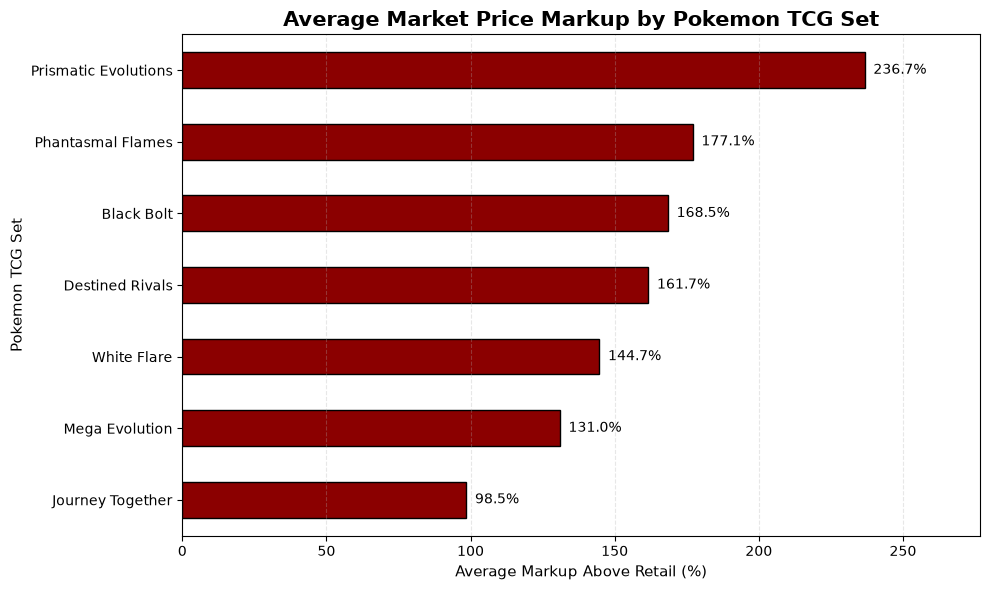

In [109]:
set_plot = set_summary["markup_percent"].sort_values()

ax = set_plot.plot(
    kind="barh",
    figsize=(10, 6),
    color="DarkRed",
    edgecolor="black"
)

plt.title(
    "Average Market Price Markup by Pokemon TCG Set",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Average Markup Above Retail (%)", fontsize=11)
plt.ylabel("Pokemon TCG Set", fontsize=11)

plt.grid(axis="x", linestyle="--", alpha=0.3)

for i, value in enumerate(set_plot):
    ax.text(
        value + 3,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=10
    )

plt.xlim(0, set_plot.max() + 40)

plt.tight_layout()
plt.show()

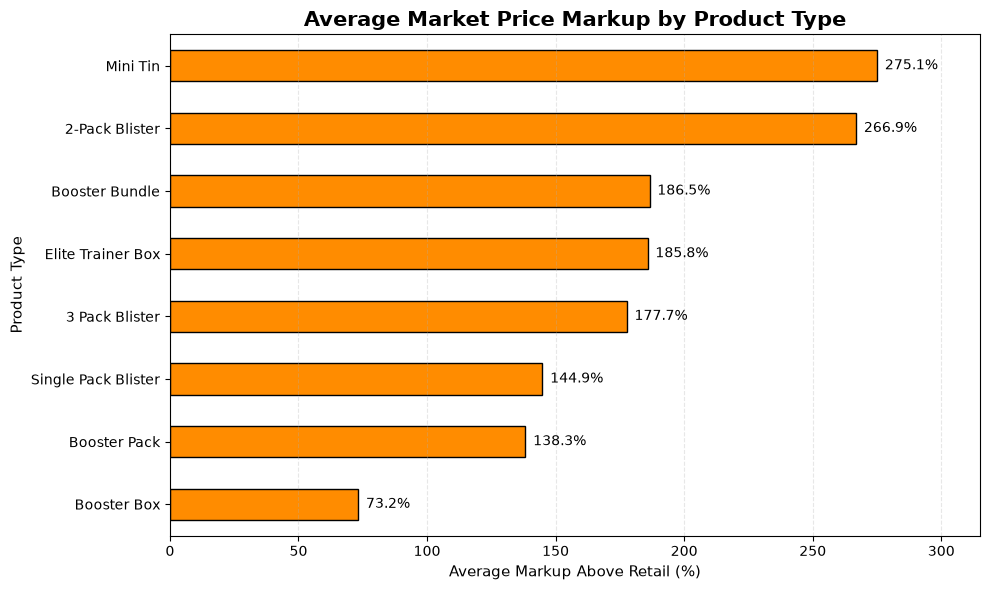

In [110]:
product_plot = product_summary["markup_percent"].sort_values()

ax = product_plot.plot(
    kind="barh",
    figsize=(10, 6),
    color="darkorange",
    edgecolor="black"
)

plt.title(
    "Average Market Price Markup by Product Type",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Average Markup Above Retail (%)", fontsize=11)
plt.ylabel("Product Type", fontsize=11)

plt.grid(axis="x", linestyle="--", alpha=0.3)

for i, value in enumerate(product_plot):
    ax.text(
        value + 3,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=10
    )

plt.xlim(0, product_plot.max() + 40)

plt.tight_layout()
plt.show()

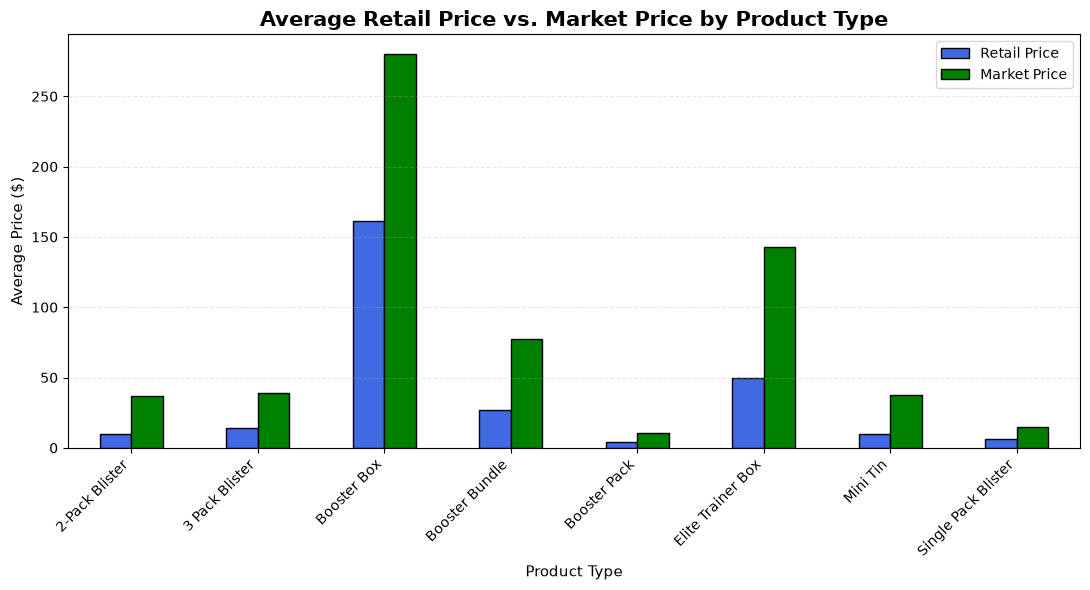

In [111]:
price_comparison = product_summary[
    ["retail_price", "market_price"]
]

ax = price_comparison.plot(
    kind="bar",
    figsize=(11, 6),
    color = ["RoyalBlue", "Green"],
    edgecolor="black"
)

plt.title(
    "Average Retail Price vs. Market Price by Product Type",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Product Type", fontsize=11)
plt.ylabel("Average Price ($)", fontsize=11)

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(["Retail Price", "Market Price"])

plt.tight_layout()
plt.show()

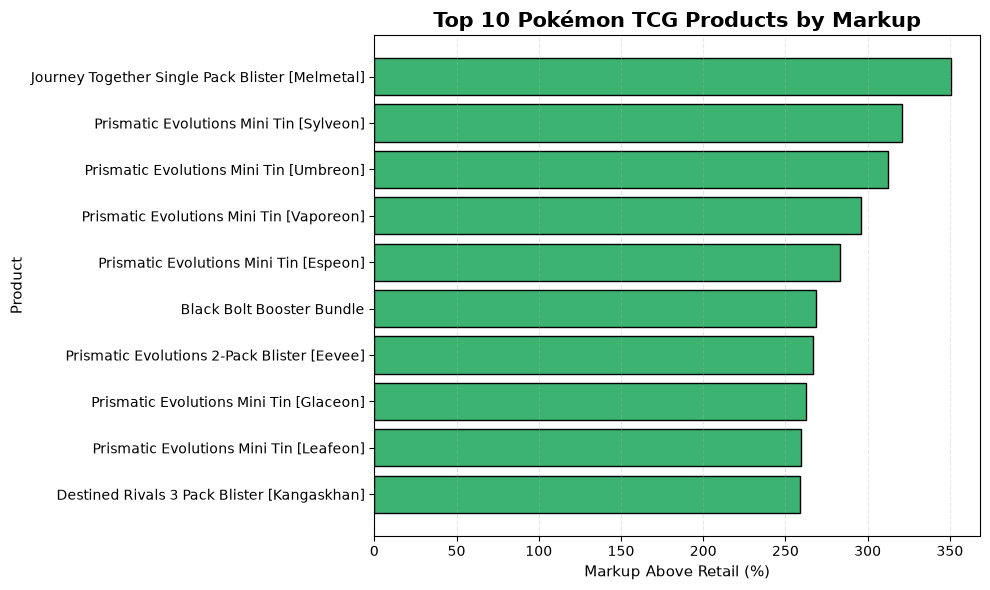

In [112]:
top_products = clean_products.nlargest(
    10,
    "markup_percent"
).sort_values("markup_percent")

plt.figure(figsize=(10, 6))

plt.barh(
    top_products["name"],
    top_products["markup_percent"],
    color="mediumseagreen",
    edgecolor="black"
)

plt.title(
    "Top 10 Pokémon TCG Products by Markup",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Markup Above Retail (%)", fontsize=11)
plt.ylabel("Product", fontsize=11)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [113]:
set_summary

,retail_price,market_price,markup_percent
searched_set,,,
Black Bolt,60.76,109.80,168.48
Destined Rivals,43.84,114.70,161.68
Journey Together,43.84,79.34,98.53
Mega Evolution,43.84,94.08,130.96
Phantasmal Flames,43.84,116.93,177.09
Prismatic Evolutions,20.28,64.30,236.73
White Flare,60.76,98.26,144.70


In [114]:
product_summary

,retail_price,market_price,markup_percent
product_type,,,
2-Pack Blister,9.99,36.65,266.90
3 Pack Blister,13.99,38.85,177.68
Booster Box,161.64,280.08,73.25
Booster Bundle,26.94,77.19,186.54
Booster Pack,4.49,10.70,138.27
Elite Trainer Box,49.99,142.87,185.79
Mini Tin,9.99,37.47,275.05
Single Pack Blister,5.99,14.67,144.88



## Research Findings

The results show that Pokemon TCG products from every set in this study were selling above the retail price baseline on average, but some sets had much larger price increases than others.

Prismatic Evolutions had the highest average markup at about 237%. Phantasmal Flames was next at about 177%, followed by Black Bolt at about 168%. Journey Together had the lowest average markup at about 99%, but its products were still selling well above the retail baseline on average.

There were also noticeable differences between product types. Mini Tins had the highest average markup at about 275%, followed by the 2-Pack Blister at about 267%. However, there was only one 2-Pack Blister in the dataset, so it would not be fair to make a strong conclusion about that product type. Booster Boxes had the lowest average markup at about 73%.

Comparing retail prices to market prices also made the price differences easier to see. For example, Booster Boxes had the highest average market price at about $280, but their percentage markup was lower than the other product types. Lower-priced products such as Mini Tins and Booster Bundles had much larger percentage increases compared to their retail price baselines.

Overall, the results show that Pokemon TCG products released in 2025 experienced noticeable price increases in the secondary market. The amount of the increase was different depending on both the set and product type. This suggests that some products became much more expensive for collectors to purchase compared to their retail price baseline.

## Limitations

There are a few limitations with the data used in this project. One of the biggest is that the market prices are a current snapshot of the products. This means the data does not show how prices changed from the day each product was released until the time the data was collected.

Another limitation is that every set does not have the same number or types of products. Some sets also have multiple versions of the same product type. To make the comparisons more balanced, I first averaged products of the same type within each set before comparing the sets and product types.

Some product types also had much less data than others. For example, there was only one 2-Pack Blister in the dataset, so its high markup does not necessarily mean that all 2-Pack Blisters would have similar markups.

The retail prices used in this project are retail price baselines collected from outside retail sources because the TCG API does not provide original retail prices. These prices give a consistent way to compare retail and secondary market prices, but they may not represent the exact price that every retailer charged when each product was released.

Finally, a product selling above retail does not automatically mean that scalping caused the increase. Popularity, product availability, demand, and the cards included in a set could also affect market prices. Because of this, this project focuses on measuring which products became more expensive compared to their retail price baseline rather than trying to prove exactly why the prices increased.

## Ethical Considerations

This project uses publicly available product and market price data and does not include personal information about individual buyers or sellers. However, it is important to be careful about how the results are interpreted.

High secondary market prices do not prove that scalpers caused the price increases. Other factors such as demand, product availability in both retail and online, popularity of certain Pokemon sets, and the cards available in each set could also affect prices. Because of this, I avoided labeling individual sellers or groups as the cause of the price increases.

The purpose of this analysis is to better understand how secondary market prices compare to retail prices and how those differences could affect collectors and fans trying to purchase Pokemon TCG products near retail price.

## Academic References

Heck, J., Schormann, S., Krichevsky, B., Groh, A., Pape, T., Schröder, S., Glahn, A., Schumacher, C., & Schulze Westhoff, M. (2026). Sales characteristics of Pokémon trading cards: A prospective one-year field study. *PLOS ONE, 21*(3), e0334289. https://doi.org/10.1371/journal.pone.0334289

Fajardo, R. (2025). Settling secondhand sales: Pricing symbolic items in an emergent online marketplace environment. *The British Journal of Sociology, 76*(2), 260–277. https://doi.org/10.1111/1468-4446.13168

Pompei, A., & Nonino, F. (2026). Trading card games as an alternative asset: Portfolio diversification and risk-return analysis. *Journal of Asset Management*. https://doi.org/10.1057/s41260-026-00467-x

## Data Sources

**TCG API:**  
The TCG API was used to collect Pokémon TCG set information, product names, and secondary market prices for the products analyzed in this project.

**Retail Price Baselines:**  
Retail price information was collected separately because the TCG API does not provide original retail prices. Retail sources such as Best Buy, Target, and Walmart were used to create consistent price baselines for Booster Packs, Booster Bundles, Booster Boxes, Elite Trainer Boxes, Blisters, and Mini Tins.

### Websites Used

- TCG API: https://tcgapi.dev/
- Walmart: https://www.walmart.com/
- Best Buy: https://www.bestbuy.com/
- Target: https://www.target.com/

These retail prices are used as comparison baselines and may not represent the exact price charged by every retailer when each product was released.

## AI Use Disclosure

I wrote the code for this project myself and used ChatGPT as a reference to help troubleshoot errors, simplify my code and check parts of my code. I also used it to help improve the organization and wording of my notebook. I reviewed and ran all of the code myself and made the final decisions about the analysis and conclusions.